In [231]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [232]:
df = pd.read_excel('citizen_health.xlsx')

## Data Cleaning:

In [233]:
df.head(n=5)

,citizen_id,country,age,gender,occupation and income_level,work_type,sleep_hours,sleep_quality,exercise_days_per_week,diet_type,fast_food_frequency,social_media_hours,stress_level,health_risk_score
0,ger_citizen1,Germany,63,Male,nan:Low,field_job,9,Good,3.0,Vegan,Medium,1,5,40
1,fra_citizen2,France,35,Female,Farmer:Low,field_job,4,Poor,5.0,Vegan,High,3,1,34
2,bra_citizen3,Brazil,35,Other,Labourer:Medium,field_job,8,Good,4.0,Vegan,Low,7,10,71
3,sou_citizen4,South Korea,34,Male,Doctor:Medium,REMOte,9,Average,1.0,Veg,Low,6,6,60
4,uk_citizen5,UK,63,Female,Business Owner:High,field_job,7,Poor,4.0,Vegan,High,1,1,18


In [234]:
df.shape

(1803, 14)

In [235]:
df.duplicated(subset='citizen_id').any()

np.True_

In [236]:
df = df.drop_duplicates(subset="citizen_id")

In [237]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   citizen_id                   1800 non-null   str    
 1   country                      1800 non-null   str    
 2   age                          1800 non-null   int64  
 3   gender                       1800 non-null   str    
 4   occupation and income_level  1800 non-null   str    
 5   work_type                    1709 non-null   str    
 6   sleep_hours                  1800 non-null   int64  
 7   sleep_quality                1800 non-null   str    
 8   exercise_days_per_week       1798 non-null   float64
 9   diet_type                    1800 non-null   str    
 10  fast_food_frequency          1799 non-null   str    
 11  social_media_hours           1800 non-null   int64  
 12  stress_level                 1800 non-null   int64  
 13  health_risk_score            

In [238]:
wrk_mode = df['work_type'].mode()[0]
wxe_mean = df['exercise_days_per_week'].mean()
fst_mode = df['fast_food_frequency'].mode()[0]

for col,val in zip(['work_type','exercise_days_per_week','fast_food_frequency'],[wrk_mode,wxe_mean,fst_mode]):
    df[col] = df[col].fillna(val)

In [239]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   citizen_id                   1800 non-null   str    
 1   country                      1800 non-null   str    
 2   age                          1800 non-null   int64  
 3   gender                       1800 non-null   str    
 4   occupation and income_level  1800 non-null   str    
 5   work_type                    1800 non-null   str    
 6   sleep_hours                  1800 non-null   int64  
 7   sleep_quality                1800 non-null   str    
 8   exercise_days_per_week       1800 non-null   float64
 9   diet_type                    1800 non-null   str    
 10  fast_food_frequency          1800 non-null   str    
 11  social_media_hours           1800 non-null   int64  
 12  stress_level                 1800 non-null   int64  
 13  health_risk_score            

## Feature Engineering:

In [240]:
df['diet_type'].unique()

<StringArray>
['Vegan', 'Veg', 'Non-Veg']
Length: 3, dtype: str

In [241]:

df['diet_type']=df['diet_type'].replace({'Vegan': 'Veg','Veg':'Veg','Non-Veg':'Non-Veg'})

In [242]:
df['occupation and income_level'].unique()

<StringArray>
[                   'nan:Low',                 'Farmer:Low',
            'Labourer:Medium',              'Doctor:Medium',
        'Business Owner:High',            'Journalist:High',
                 'Driver:Low',             'Journalist:Low',
      'Graphic Designer:High',      'Police Officer:Medium',
              'Driver:Medium',      'Business Owner:Medium',
                 'Gamer:High',               'Engineer:Low',
               'Labourer:Low',            'Politician:High',
   'Government Employee:High',             'Politician:Low',
             'Teacher:Medium',             'Scientist:High',
         'Business Owner:Low',           'Scientist:Medium',
               'Nurse:Medium',         'Factory Worker:Low',
                'Driver:High',                'Lawyer:High',
                  'Student:0',               'Gamer:Medium',
                'Teacher:Low',                  'Nurse:Low',
                 'Nurse:High',                 'Lawyer:Low',
    'Gover

In [243]:
df[['occupation','income_level']] = df['occupation and income_level'].str.split(":",expand=True)
df.drop(columns=['occupation and income_level'],inplace=True)

df['name'] = df['citizen_id'].str.rstrip('0123456789')
df['citizen-id'] = df['citizen_id'].str.extract('(\d+)')
df.drop(columns=['citizen_id'],inplace=True)

<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\MUKESH\AppData\Local\Temp\ipykernel_23620\292075582.py:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['citizen-id'] = df['citizen_id'].str.extract('(\d+)')


In [244]:
df.columns

Index(['country', 'age', 'gender', 'work_type', 'sleep_hours', 'sleep_quality',
       'exercise_days_per_week', 'diet_type', 'fast_food_frequency',
       'social_media_hours', 'stress_level', 'health_risk_score', 'occupation',
       'income_level', 'name', 'citizen-id'],
      dtype='str')

In [245]:
lst = ['citizen-id','name','country', 'age', 'gender', 'work_type', 'sleep_hours', 'sleep_quality',
       'exercise_days_per_week', 'diet_type', 'fast_food_frequency',
       'social_media_hours', 'stress_level', 'health_risk_score', 'occupation',
       'income_level']
df=df[lst]
df

,citizen-id,name,country,age,gender,work_type,sleep_hours,sleep_quality,exercise_days_per_week,diet_type,fast_food_frequency,social_media_hours,stress_level,health_risk_score,occupation,income_level
0,1,ger_citizen,Germany,63,Male,field_job,9,Good,3.0,Veg,Medium,1,5,40,nan,Low
1,2,fra_citizen,France,35,Female,field_job,4,Poor,5.0,Veg,High,3,1,34,Farmer,Low
2,3,bra_citizen,Brazil,35,Other,field_job,8,Good,4.0,Veg,Low,7,10,71,Labourer,Medium
3,4,sou_citizen,South Korea,34,Male,REMOte,9,Average,1.0,Veg,Low,6,6,60,Doctor,Medium
4,5,uk_citizen,UK,63,Female,field_job,7,Poor,4.0,Veg,High,1,1,18,Business Owner,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,1796,new_citizen,New Zealand,43,Other,REMOte,8,Poor,4.0,Veg,Low,6,8,58,Teacher,Medium
1796,1797,mex_citizen,Mexico,65,Male,field_job,9,Poor,2.0,Veg,Low,5,8,62,Business Owner,High
1797,1798,uae_citizen,UAE,48,Female,desk_job,4,Poor,0.0,Veg,Low,3,5,54,Farmer,High
1798,1799,ger_citizen,Germany,52,Male,hybrid,5,Good,3.0,Non-Veg,Low,4,6,57,Gamer,Low


In [246]:
df.reset_index(drop=True)

,citizen-id,name,country,age,gender,work_type,sleep_hours,sleep_quality,exercise_days_per_week,diet_type,fast_food_frequency,social_media_hours,stress_level,health_risk_score,occupation,income_level
0,1,ger_citizen,Germany,63,Male,field_job,9,Good,3.0,Veg,Medium,1,5,40,nan,Low
1,2,fra_citizen,France,35,Female,field_job,4,Poor,5.0,Veg,High,3,1,34,Farmer,Low
2,3,bra_citizen,Brazil,35,Other,field_job,8,Good,4.0,Veg,Low,7,10,71,Labourer,Medium
3,4,sou_citizen,South Korea,34,Male,REMOte,9,Average,1.0,Veg,Low,6,6,60,Doctor,Medium
4,5,uk_citizen,UK,63,Female,field_job,7,Poor,4.0,Veg,High,1,1,18,Business Owner,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,1796,new_citizen,New Zealand,43,Other,REMOte,8,Poor,4.0,Veg,Low,6,8,58,Teacher,Medium
1796,1797,mex_citizen,Mexico,65,Male,field_job,9,Poor,2.0,Veg,Low,5,8,62,Business Owner,High
1797,1798,uae_citizen,UAE,48,Female,desk_job,4,Poor,0.0,Veg,Low,3,5,54,Farmer,High
1798,1799,ger_citizen,Germany,52,Male,hybrid,5,Good,3.0,Non-Veg,Low,4,6,57,Gamer,Low


## Data Analysis and Visualization:

Which occupation groups have the highest average health_risk_score?

In [247]:
df.groupby('occupation')['health_risk_score'].mean().sort_values(ascending=False)

occupation
Journalist             54.614583
Labourer               54.146067
Driver                 53.858696
Police Officer         53.609195
Teacher                53.308642
Farmer                 53.073684
Doctor                 52.901235
Lawyer                 52.827957
Government Employee    52.768421
Nurse                  52.568421
Gamer                  52.505376
Chef                   52.302326
Politician             52.087912
Student                51.351648
Graphic Designer       51.194805
Factory Worker         51.010417
Scientist              50.756098
Influencer             48.836957
Business Owner         48.693069
Engineer               46.127907
nan                    40.000000
Name: health_risk_score, dtype: float64

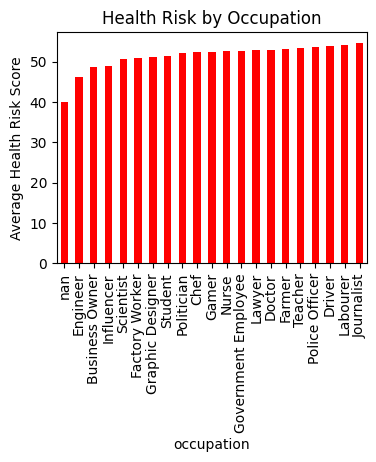

In [297]:
plt.figure(figsize=(4,3))
df.groupby('occupation')['health_risk_score'].mean().sort_values().plot(kind='bar',color='red')
plt.title("Health Risk by Occupation")
plt.ylabel("Average Health Risk Score")
plt.show()

<--Observation-->

Journalist occupation group have more average health risk score. Followed by Labaurer

Is there a relationship between social_media_hours and stress_level?

In [248]:
df[['social_media_hours','stress_level']].corr()

,social_media_hours,stress_level
social_media_hours,1.000000,0.006571
stress_level,0.006571,1.000000


<--Observation-->

No-relation between social_media_hours and stress_level.

What is the average health_risk_score by country?

In [249]:
df.groupby('country')['health_risk_score'].mean().sort_values(ascending=False)

country
South Korea     54.120000
Germany         53.901639
UAE             53.585714
South Africa    53.396396
Australia       52.880342
USA             52.552846
Singapore       52.514019
Brazil          52.354331
India           51.862595
Japan           51.772727
Mexico          51.129771
UK              51.000000
France          50.371429
Canada          48.756098
New Zealand     48.218487
Name: health_risk_score, dtype: float64

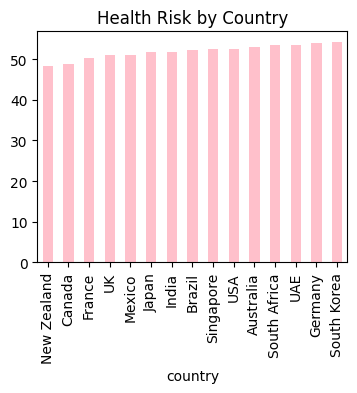

In [298]:
plt.figure(figsize=(4,3))
df.groupby('country')['health_risk_score'].mean().sort_values().plot(kind='bar',color='pink')
plt.title("Health Risk by Country")
plt.show()

<-- Observation -->

More health risk score is have the south korea and followed by Germony, UAE.

How does exercise_days_per_week impact health_risk_score?

In [250]:
df.groupby('exercise_days_per_week')['health_risk_score'].mean()

exercise_days_per_week
0.000000    58.597345
1.000000    59.121339
2.000000    52.771300
3.000000    52.187755
3.432147    47.000000
4.000000    46.176744
5.000000    49.263393
6.000000    49.265403
7.000000    46.883721
Name: health_risk_score, dtype: float64

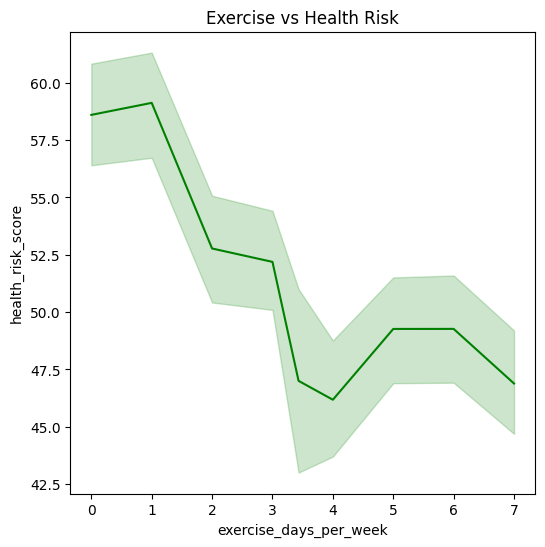

In [302]:
plt.figure(figsize=(6,6))
sns.lineplot(x='exercise_days_per_week', y='health_risk_score', data=df,color='green')
plt.title("Exercise vs Health Risk")
plt.show()

<-- Observation -->

Negative relationship bcz more exercise will return Lower health risk



Do people who sleep less than 6 hours have higher stress levels?

In [251]:
df[df['sleep_hours'] >= 6]['stress_level'].mean()

np.float64(5.520973154362416)

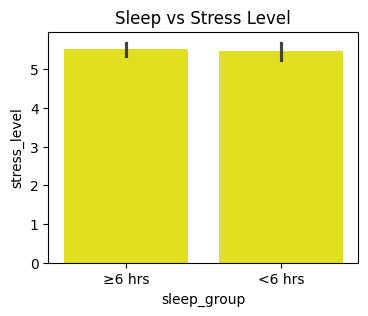

In [288]:
sleep_data = df.copy()
sleep_data['sleep_group'] = sleep_data['sleep_hours'].apply(lambda x: '<6 hrs' if x < 6 else '≥6 hrs')

plt.figure(figsize=(4,3))
sns.barplot(x='sleep_group', y='stress_level',color='yellow',data=sleep_data)
plt.title("Sleep vs Stress Level")
plt.show()

observation

People who sleep ≥ 6 hours have an average stress level of ~5.52

Does fast_food_frequency affect health_risk_score?

In [252]:
df.groupby('fast_food_frequency')['health_risk_score'].mean()

fast_food_frequency
High      57.741652
Low       45.586777
Medium    52.753994
Name: health_risk_score, dtype: float64

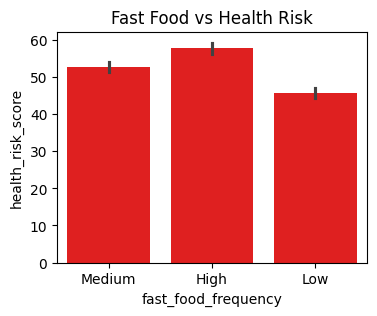

In [292]:
plt.figure(figsize=(4,3))
sns.barplot(x='fast_food_frequency', y='health_risk_score',color='red', data=df)
plt.title("Fast Food vs Health Risk")
plt.show()

observation

Frequent fast food intake is clearly associated with higher health risk.

Which work_type has the highest health_risk_score?

In [253]:
df.groupby('work_type')['health_risk_score'].mean().sort_values(ascending=False)

work_type
desk_job     52.861809
field_job    51.727700
REMOte       51.636029
hybrid       51.606481
Name: health_risk_score, dtype: float64

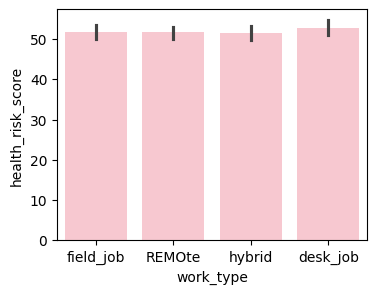

In [272]:
plt.figure(figsize=(4,3))
sns.barplot(df,x='work_type',y='health_risk_score',color='pink')
plt.show()

observation

Desk jobs have the highest health risk compared to all other.

How does age group affect health_risk_score?

In [255]:
df['age_group'] = pd.cut(df['age'], bins=[0,20,40,60,100], labels=['Young','Adult','Middle Age','Senior'])
df.groupby('age_group')['health_risk_score'].mean()

age_group
Young         52.343137
Adult         51.847594
Middle Age    51.616083
Senior        53.307263
Name: health_risk_score, dtype: float64

In [269]:
df.columns

Index(['citizen-id', 'name', 'country', 'age', 'gender', 'work_type',
       'sleep_hours', 'sleep_quality', 'exercise_days_per_week', 'diet_type',
       'fast_food_frequency', 'social_media_hours', 'stress_level',
       'health_risk_score', 'occupation', 'income_level', 'age_group'],
      dtype='str')

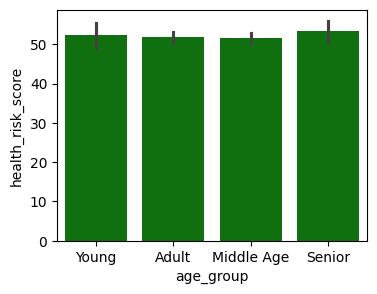

In [273]:
plt.figure(figsize=(4,3))
sns.barplot(df,x='age_group',y='health_risk_score',color='green')
plt.show()

observation

Senior age group peoples can be affected More.

Do stress levels or health risks differ across genders?

In [ ]:
df.groupby('gender')[['stress_level','health_risk_score']].mean()

,stress_level,health_risk_score
gender,,
Female,5.629085,52.933007
Male,5.395833,51.048611
Other,5.468954,51.732026


<Figure size 700x700 with 0 Axes>

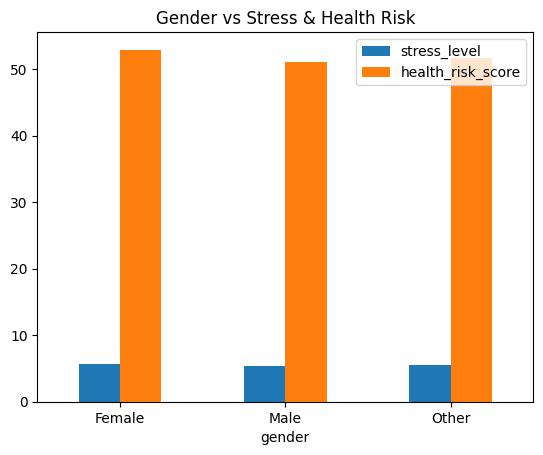

In [304]:
plt.figure(figsize=(7,7))
df.groupby('gender')[['stress_level','health_risk_score']].mean().plot(kind='bar')
plt.title("Gender vs Stress & Health Risk")
plt.xticks(rotation=0)
plt.show()

observation

Females have the highest average stress level (5.63) and health risk score (52.93) among all groups.


Which Lifestyle Factor Impacts Health the Most?

In [ ]:
df.corr(numeric_only=True)['health_risk_score'].sort_values(ascending=False)

health_risk_score         1.000000
stress_level              0.810583
social_media_hours        0.420254
age                       0.001499
sleep_hours              -0.187914
exercise_days_per_week   -0.223239
Name: health_risk_score, dtype: float64

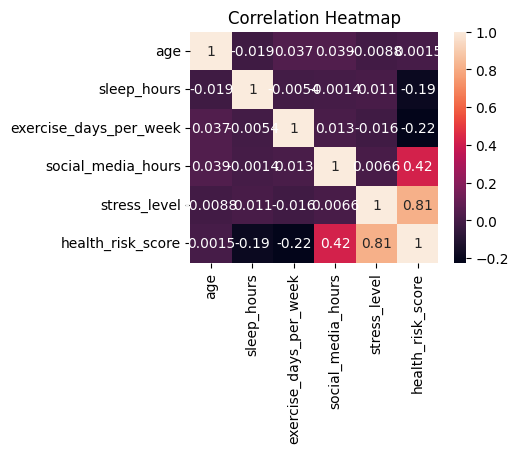

In [275]:
plt.figure(figsize=(4,3))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

observation

Stress level is the biggest contributor to health risk
